In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
import seaborn as sns
from network_idx.eda.correlations import fetch_data_from_bq

In [2]:
# Fetch data from bq
tract_df = fetch_data_from_bq()

Error: Credentials file not found


/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [3]:
# Rework tract_df to obtain meaningful relationships
tract_df_modified = tract_df.copy()
techs = ['copper','cable','fiber']
for tech in techs:
    tract_df_modified[f'{tech}_equal_more_than_100_20_units'] = tract_df_modified[f"{tech}_speed_100_20_only"].add(tract_df_modified[f"{tech}_speed_more_than_100_20"], fill_value=0)

# Compute % growth parcels
tract_df_modified['perc_growth_parcels'] = round(tract_df_modified['growth_parcels'] / tract_df_modified['total_parcels'],2)


# Remove redundant columns that are not relevant for the analysis
cols_to_drop = ['copper_speed_less_than_100_20',
                'copper_speed_100_20_only',
                'copper_speed_more_than_100_20',
                'cable_speed_less_than_100_20',
                'cable_speed_100_20_only',
                'cable_speed_more_than_100_20',
                'fiber_speed_less_than_100_20',
                'fiber_speed_100_20_only',
                'fiber_speed_more_than_100_20',
                'fiber_speed_equal_greater_than_100_20',
                #'cable_location_count',
                #'copper_location_count',
                #'fiber_location_count'
                'copper_max_upload_speed',
                'cable_max_upload_speed',
                'fiber_max_upload_speed',
                'total_parcels',
                'growth_parcels',
                'unique_locations',
                'total_flags',
                'flags_minus_greatest'
                ]

# Remove the columns that are not relevant for the analysis
tract_df_modified = tract_df_modified.drop(columns=cols_to_drop)

# Examine columns
tract_df_modified.info()

<class 'pandas.DataFrame'>
RangeIndex: 85481 entries, 0 to 85480
Data columns (total 28 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   tract_geoid                          85481 non-null  str    
 1   pop_ch_1yr                           84178 non-null  float64
 2   pop_pctch_1yr                        84169 non-null  float64
 3   estimated_census_housing_units       85481 non-null  int64  
 4   estimated_fcc_units                  85481 non-null  int64  
 5   cable_location_count                 84909 non-null  float64
 6   cable_provider_count                 82151 non-null  float64
 7   cable_max_download_speed             82151 non-null  float64
 8   copper_location_count                84909 non-null  float64
 9   copper_provider_count                68752 non-null  float64
 10  copper_max_download_speed            68752 non-null  float64
 11  fiber_location_count                 84

In [5]:
# Examine thresholds for growth features with counts
features = ['pre_early_dev_parcels', 'landuse_change_count', 
            'builder_developer_count', 'building_permit_count']

for col in features:
    zero_pct = (tract_df_modified[col] == 0).mean() * 100
    print(f"{col}: {zero_pct:.1f}% zeros")

pre_early_dev_parcels: 43.0% zeros
landuse_change_count: 61.4% zeros
builder_developer_count: 59.7% zeros
building_permit_count: 68.0% zeros


In [15]:
# Percentile checks
print("\n Overall Percentiles (all observations):")
print("=="*60)
for col in features:
    print(f"{col}: median={tract_df_modified[col].median()}, "
          f"P25={tract_df_modified[col].quantile(0.25)}, "
          f"P75={tract_df_modified[col].quantile(0.75)}")
    
print("=="*60)
print("\nPercentiles for growth features with non-zero counts:")
print("=="*60)
for col in features:
    non_zero = tract_df_modified[col][tract_df_modified[col] > 0]
    print(f"{col} (non-zero): median={non_zero.median()}, "
          f"P25={non_zero.quantile(0.25)}, P75={non_zero.quantile(0.75)}")




 Overall Percentiles (all observations):
pre_early_dev_parcels: median=1.0, P25=0.0, P75=11.0
landuse_change_count: median=0.0, P25=0.0, P75=2.0
builder_developer_count: median=0.0, P25=0.0, P75=2.0
building_permit_count: median=0.0, P25=0.0, P75=1.0

Percentiles for growth features with non-zero counts:
pre_early_dev_parcels (non-zero): median=8.0, P25=2.0, P75=28.0
landuse_change_count (non-zero): median=3.0, P25=1.0, P75=8.0
builder_developer_count (non-zero): median=3.0, P25=1.0, P75=9.0
building_permit_count (non-zero): median=3.0, P25=1.0, P75=9.0


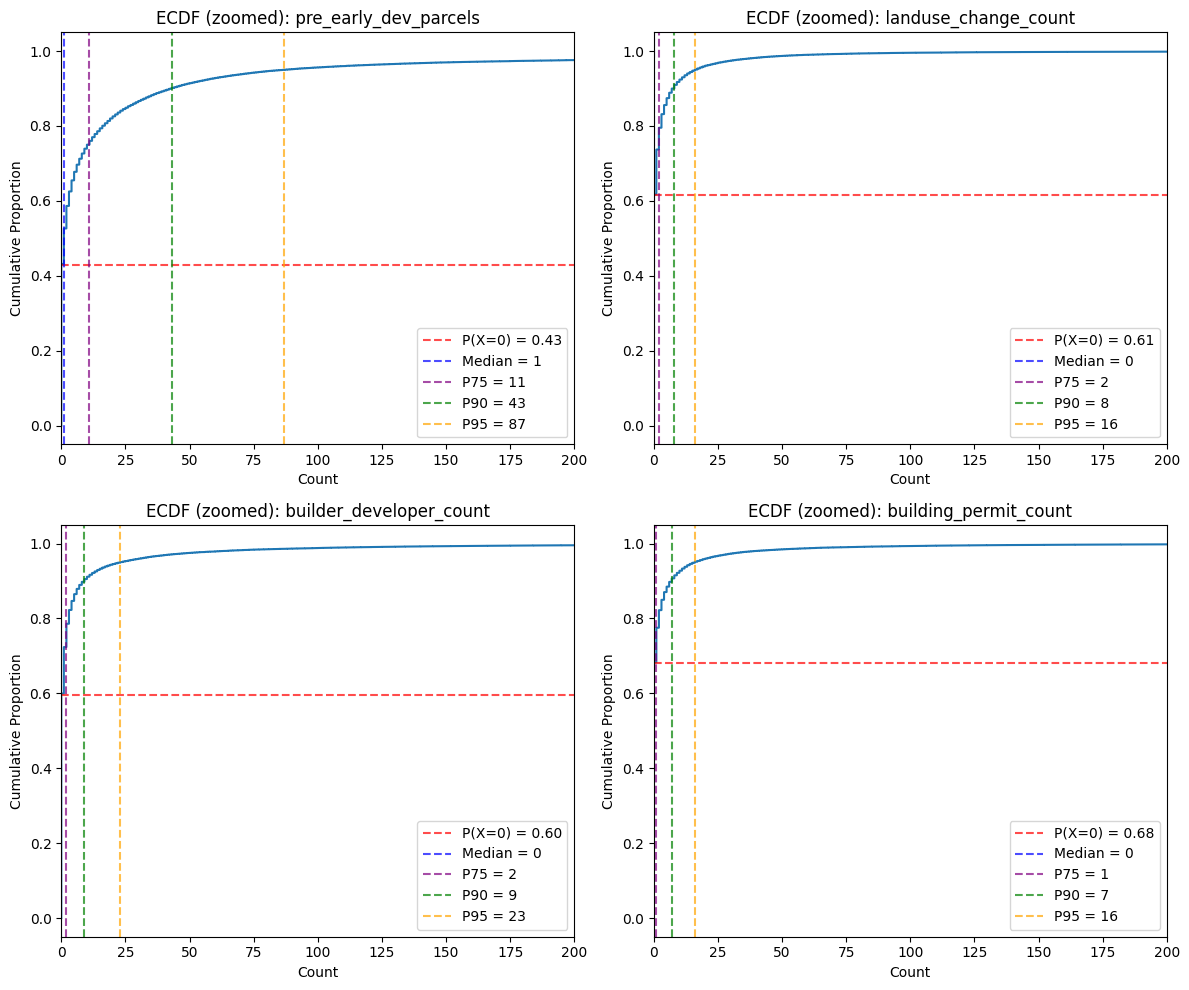

In [ ]:
# Plotting CDFs
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, col in zip(axes.flatten(), features):
    sorted_vals = np.sort(tract_df_modified[col].dropna())
    ecdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    ax.plot(sorted_vals, ecdf)
    
    # Zoom into 0-500 range
    ax.set_xlim(0, 200)
    
    # Mark the cumulative proportion at count=0 (i.e., % of zeros)
    zero_prop = (tract_df_modified[col] == 0).mean()
    ax.axhline(zero_prop, color='red', linestyle='--', alpha=0.7, label=f'P(X=0) = {zero_prop:.2f}')
    ax.axvline(0, color='grey', linestyle=':', alpha=0.5)
    
    # Mark where 90th and 95th percentiles fall
    p50 = tract_df_modified[col].quantile(0.50)
    p75 = tract_df_modified[col].quantile(0.75)
    p90 = tract_df_modified[col].quantile(0.90)
    p95 = tract_df_modified[col].quantile(0.95)
    ax.axvline(p50, color='blue', linestyle='--', alpha=0.7, label=f'Median = {p50:.0f}')
    ax.axvline(p75, color='purple', linestyle='--', alpha=0.7, label=f'P75 = {p75:.0f}')
    ax.axvline(p90, color='green', linestyle='--', alpha=0.7, label=f'P90 = {p90:.0f}')
    ax.axvline(p95, color='orange', linestyle='--', alpha=0.7, label=f'P95 = {p95:.0f}')
    
    ax.set_title(f'ECDF (zoomed): {col}')
    ax.set_xlabel('Count')
    ax.set_ylabel('Cumulative Proportion')
    ax.legend(loc='lower right')
plt.tight_layout()